# 📘 Logistic Regression & Decision Boundary

## 🎯 Learning Objectives (Interview-Ready)

By the end of this notebook, you will understand:
1. **What is Logistic Regression?** – A classification algorithm (not regression) that models probability using the sigmoid function.
2. **Sigmoid / Logit Function** – How it maps any real value to [0,1].
3. **Decision Boundary** – The line (or curve) separating classes, defined by $P(Y=1|X) = 0.5$.
4. **Coefficient Interpretation** – How feature changes affect log-odds.
5. **Performance Metrics** – Confusion matrix, precision, recall, F1, ROC-AUC.
6. **Regularization** – L1 (Lasso) and L2 (Ridge) for logistic regression.

> 💡 **Key interview point**: Logistic regression outputs probabilities; the default decision boundary is at 0.5, but you can shift it based on business needs (cost-sensitive learning).

In [ ]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve)
from sklearn.preprocessing import StandardScaler

# Set style for professional plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Synthetic Dataset – Linearly Separable

We create a 2-feature dataset to easily visualize the decision boundary.

In [2]:
# Generate 2D dataset with 2 classes
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=42, flip_y=0.05)

# Convert to DataFrame for easy manipulation
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Target'] = y

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features (important for regularized logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test): {np.bincount(y_test)}")

Training set size: 210
Test set size: 90
Class distribution (train): [106 104]
Class distribution (test): [45 45]


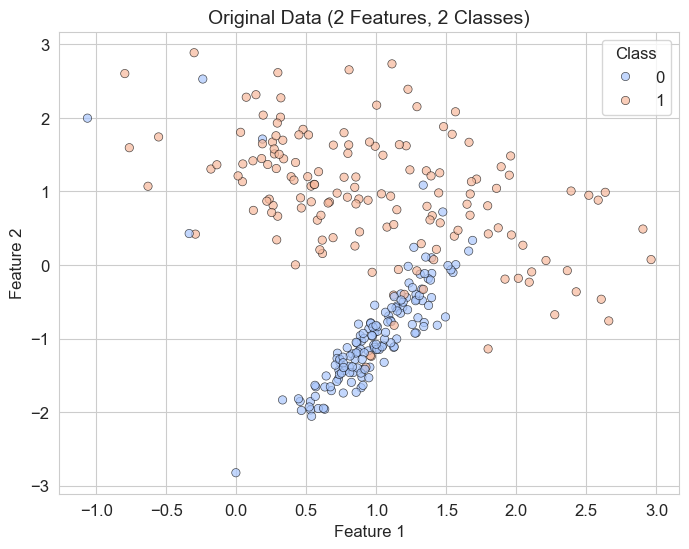

In [3]:
# Visualize the raw data
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Target', palette='coolwarm', alpha=0.7, edgecolor='k')
plt.title('Original Data (2 Features, 2 Classes)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Class')
plt.show()

## 2. Train Logistic Regression Model

We use `liblinear` solver for smaller datasets. Key hyperparameters:
- `C`: Inverse regularization strength (small C = strong regularization)
- `penalty`: 'l2' (default) or 'l1'

In [4]:
# Train logistic regression
log_reg = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Get coefficients and intercept
coef_1, coef_2 = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

print("="*50)
print("📊 Model Parameters (on scaled features)")
print("="*50)
print(f"Coefficient for Feature 1: {coef_1:.4f}")
print(f"Coefficient for Feature 2: {coef_2:.4f}")
print(f"Intercept: {intercept:.4f}")
print("\n📐 Decision boundary equation (scaled space):")
print(f"{coef_1:.4f} * x1 + {coef_2:.4f} * x2 + {intercept:.4f} = 0")

📊 Model Parameters (on scaled features)
Coefficient for Feature 1: 0.4217
Coefficient for Feature 2: 3.0625
Intercept: -0.0061

📐 Decision boundary equation (scaled space):
0.4217 * x1 + 3.0625 * x2 + -0.0061 = 0


c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 3. Decision Boundary Visualization (Original Scale)

We transform back to original feature space to plot the boundary correctly.

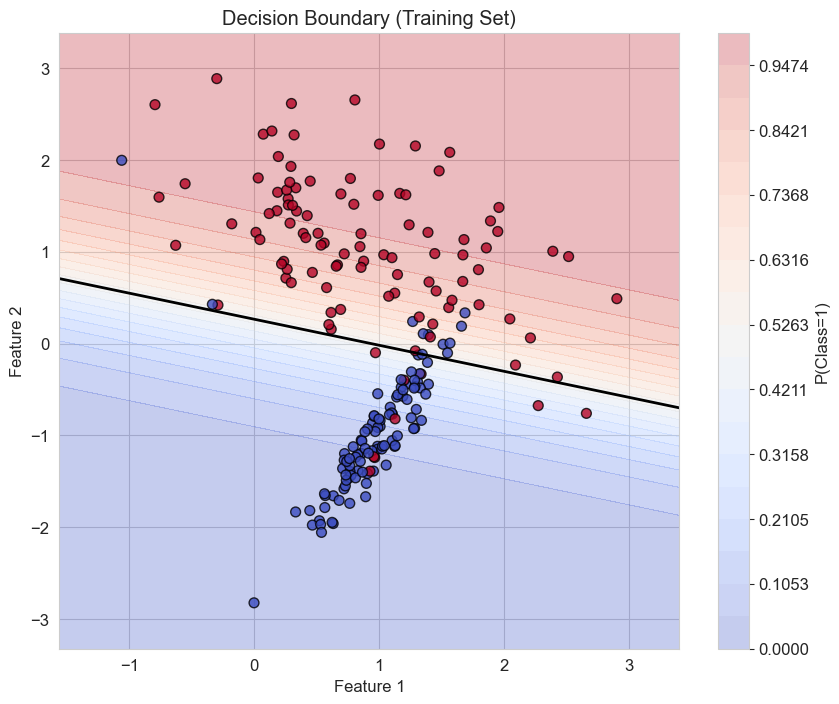

In [ ]:
# Function to plot decision boundary
def plot_decision_boundary(model, X, y, scaler, ax=None, title='Decision Boundary'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Create meshgrid in original space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Scale the mesh points
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)

    # Predict probabilities
    Z = model.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

    # Plot contour of probability = 0.5 (decision boundary)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='-')
    # Also show probability heatmap
    contourf = ax.contourf(xx, yy, Z, levels=np.linspace(0,1,20), alpha=0.3, cmap='coolwarm')

    # Scatter plot original data
    scatter = ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', s=50, alpha=0.8)

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    plt.colorbar(contourf, ax=ax, label='P(Class=1)')
    return ax

# Plot
fig, ax = plt.subplots(figsize=(10,8))
plot_decision_boundary(log_reg, X_train, y_train, scaler, ax, title='Decision Boundary (Training Set)')
plt.show()

## 4. Predictions & Probability Outputs

Logistic regression gives **probabilities**, not just class labels.

In [6]:
# Predict probabilities and classes
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = log_reg.predict(X_test_scaled)

# Create results DataFrame
results = pd.DataFrame({
    'True_Class': y_test,
    'Predicted_Class': y_pred,
    'Prob_Class_1': y_pred_prob
})
results.head(10)

,True_Class,Predicted_Class,Prob_Class_1
0,1,1,0.872237
1,1,1,0.990305
2,0,0,0.077698
3,0,0,0.007290
4,1,1,0.505078
5,1,1,0.849265
6,0,0,0.198883
7,0,1,0.539983
8,0,0,0.006300
9,1,1,0.947301


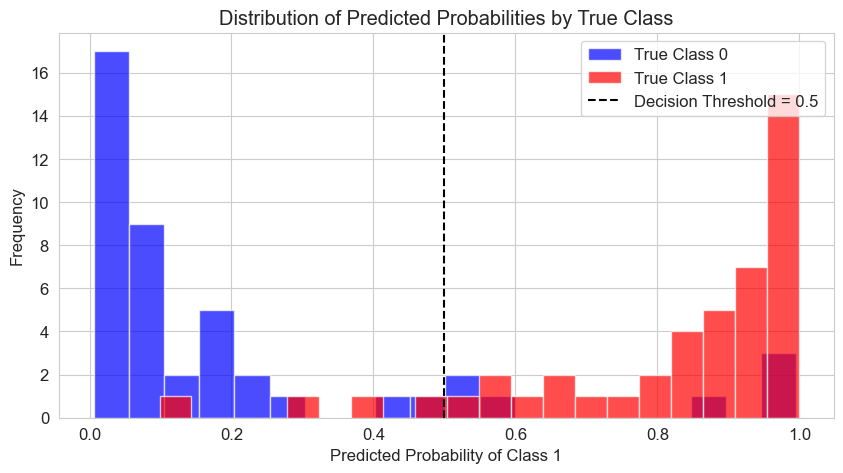

In [7]:
# Histogram of predicted probabilities
plt.figure(figsize=(10,5))
plt.hist(y_pred_prob[y_test==0], bins=20, alpha=0.7, label='True Class 0', color='blue')
plt.hist(y_pred_prob[y_test==1], bins=20, alpha=0.7, label='True Class 1', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Decision Threshold = 0.5')
plt.xlabel('Predicted Probability of Class 1')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities by True Class')
plt.legend()
plt.show()

## 5. Model Evaluation – Classification Metrics

Confusion matrix, precision, recall, F1-score.

Confusion Matrix:
[[38  7]
 [ 3 42]]


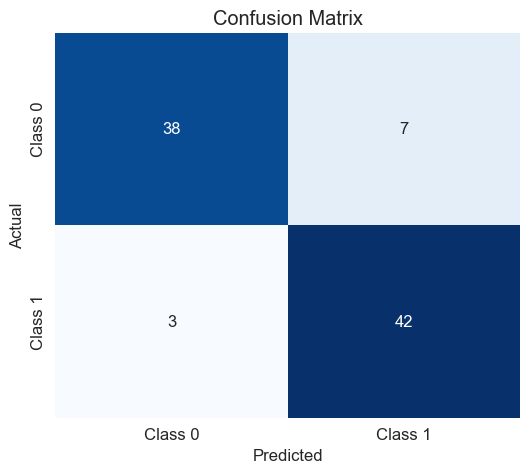


📈 Classification Report
              precision    recall  f1-score   support

     Class 0       0.93      0.84      0.88        45
     Class 1       0.86      0.93      0.89        45

    accuracy                           0.89        90
   macro avg       0.89      0.89      0.89        90
weighted avg       0.89      0.89      0.89        90



In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visual confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\n" + "="*60)
print("📈 Classification Report")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

## 6. ROC Curve & AUC

ROC curve shows trade-off between TPR and FPR. AUC tells how well the model separates classes.

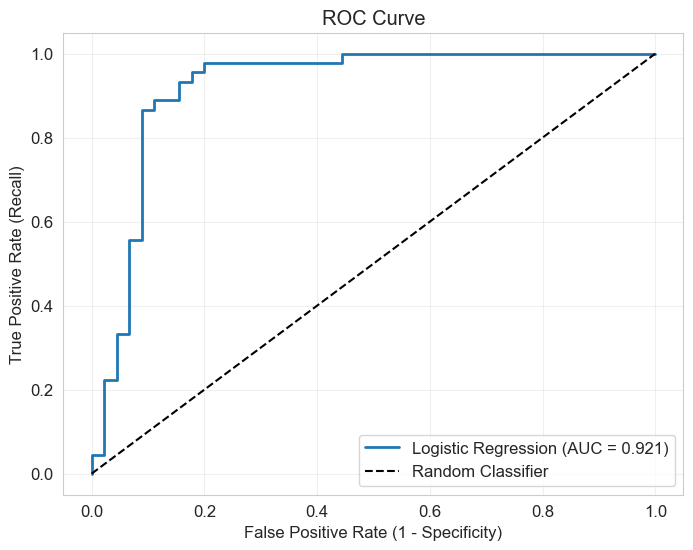

In [9]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Precision-Recall Curve

Important for imbalanced datasets.

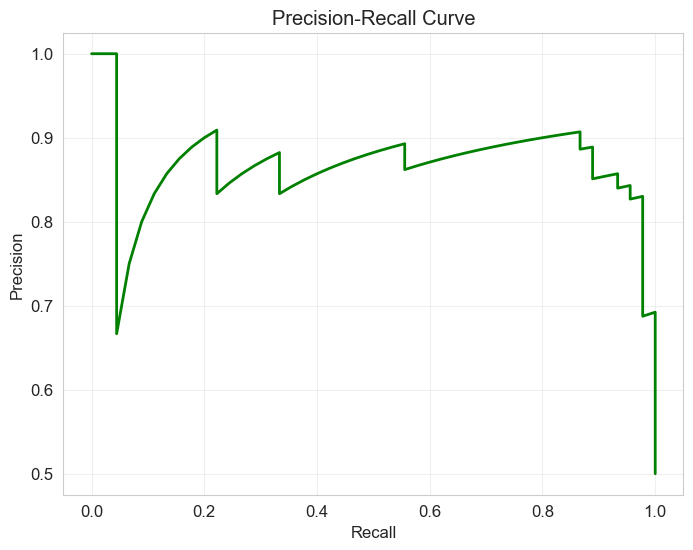

In [10]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.show()

## 8. Effect of Regularization (L1 vs L2)

Regularization prevents overfitting. L1 can drive coefficients to zero (feature selection).

c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is dep

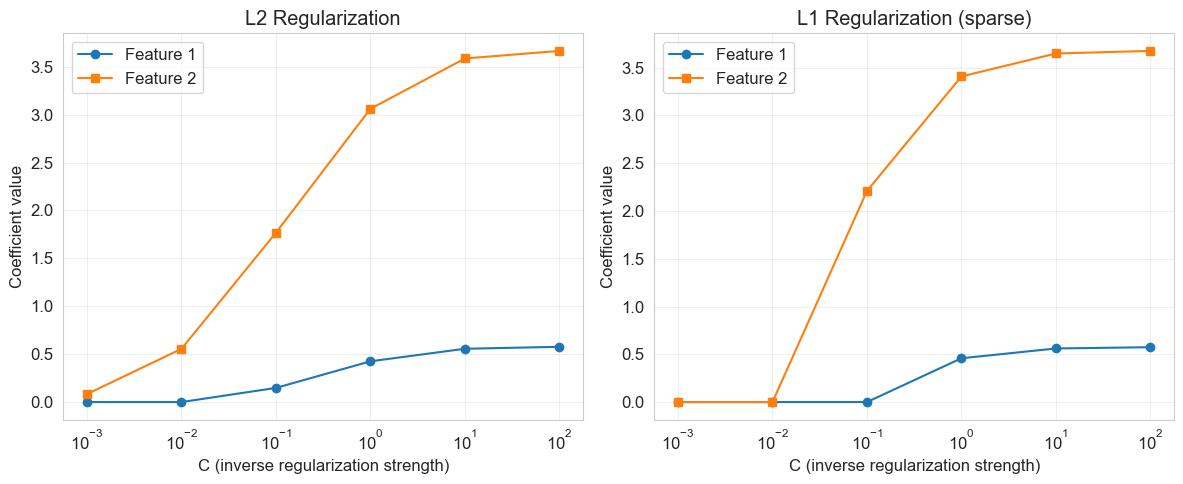

In [ ]:
# Compare different regularization strengths
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
coef_l2 = []
coef_l1 = []

for C in C_values:
    # L2
    lr_l2 = LogisticRegression(C=C, penalty='l2', solver='liblinear', random_state=42)
    lr_l2.fit(X_train_scaled, y_train)
    coef_l2.append(lr_l2.coef_[0])

    # L1
    lr_l1 = LogisticRegression(C=C, penalty='l1', solver='liblinear', random_state=42)
    lr_l1.fit(X_train_scaled, y_train)
    coef_l1.append(lr_l1.coef_[0])

coef_l2 = np.array(coef_l2)
coef_l1 = np.array(coef_l1)

# Plot coefficient paths
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(C_values, coef_l2[:,0], 'o-', label='Feature 1')
axes[0].plot(C_values, coef_l2[:,1], 's-', label='Feature 2')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (inverse regularization strength)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('L2 Regularization')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(C_values, coef_l1[:,0], 'o-', label='Feature 1')
axes[1].plot(C_values, coef_l1[:,1], 's-', label='Feature 2')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (inverse regularization strength)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('L1 Regularization (sparse)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Non-Linear Decision Boundaries

Logistic regression is linear by default. To get non-linear boundaries, we add polynomial features.

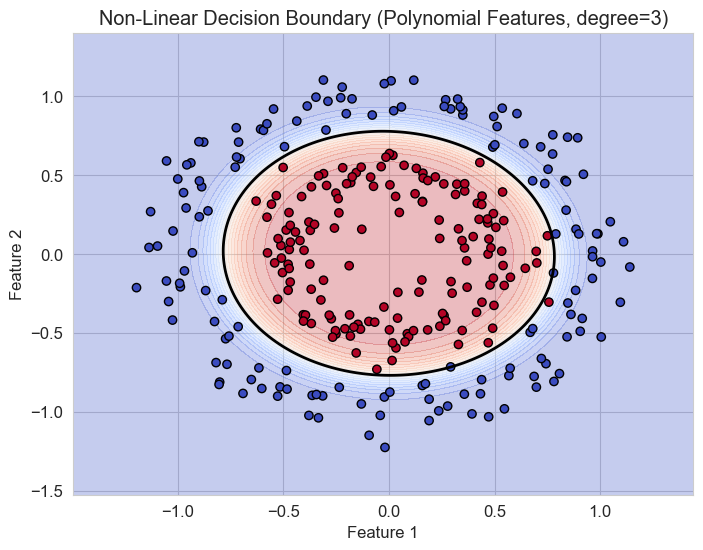

In [ ]:
# Create non-linear dataset (circles)
from sklearn.datasets import make_circles
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

X_circ, y_circ = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)

# Train logistic regression with polynomial features
poly_log_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(C=1, solver='liblinear'))
])

poly_log_reg.fit(X_circ, y_circ)

# Plot decision boundary
def plot_poly_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    y_min, y_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, levels=20, alpha=0.3, cmap='coolwarm')
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title('Non-Linear Decision Boundary (Polynomial Features, degree=3)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_poly_decision_boundary(poly_log_reg, X_circ, y_circ)

## 10. Key Interview Q&A

### ❓ Q1: Is logistic regression a regression or classification algorithm?
✅ **A:** Despite its name, it's a **classification** algorithm. It models the probability of belonging to a class.

### ❓ Q2: What is the cost function optimized in logistic regression?
✅ **A:** Log Loss (Binary Cross-Entropy):  
$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)}\log(h_\theta(x^{(i)})) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))]$

### ❓ Q3: How do you handle imbalanced data with logistic regression?
✅ **A:** 
- Use `class_weight='balanced'` in sklearn
- Adjust decision threshold (not always 0.5)
- Use sampling techniques (SMOTE, undersampling)

### ❓ Q4: What is the difference between L1 and L2 regularization?
✅ **A:** 
- **L2 (Ridge)**: Shrinks coefficients but keeps all features
- **L1 (Lasso)**: Can drive coefficients to exactly zero → feature selection

### ❓ Q5: Can logistic regression handle non-linear boundaries?
✅ **A:** Yes, by adding polynomial features, interaction terms, or using kernel tricks (though SVM is more common for kernels).

### ❓ Q6: How to interpret coefficients?
✅ **A:** For a 1-unit increase in feature $x_j$, the **log-odds** of the outcome increase by $\beta_j$. For probability, it's multiplicative on odds: $Odds$ multiplies by $e^{\beta_j}$.

### ❓ Q7: What happens if features are highly correlated?
✅ **A:** Coefficients become unstable, variance increases. Use regularization (L2) or dimensionality reduction (PCA).

### ❓ Q8: What is the difference between logistic regression and linear regression?
✅ **A:** 
| Aspect | Linear Regression | Logistic Regression |
|--------|------------------|----------------------|
| Output | Continuous | Probability [0,1] |
| Link function | Identity | Logit |
| Loss | MSE | Log Loss |
| Task | Regression | Classification |

## ✅ Summary – Professional Takeaway

- **Logistic Regression** is a **linear classifier** using the sigmoid function to output probabilities.
- **Decision boundary** is where $P(Y=1|X) = 0.5$, i.e., $\beta^T X = 0$.
- **Interpretability** is a key strength – coefficients tell you direction and magnitude of feature impact on log-odds.
- **Regularization** is essential when features are many or correlated.
- **Evaluation** should always include precision/recall and ROC-AUC, not just accuracy.
- **Non-linear boundaries** require feature engineering (polynomials, interactions).

> 💼 **For interviews**: Be ready to derive the decision boundary equation, explain log-odds, and discuss when to change the classification threshold.